In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

import seqdata as sd
import seqpro as sp

from cpgnet import CpGNet  # Replace with the correct path to your CpGNet implementation
from cpgnet.losses import BNLLLoss  # Replace with your BNLL loss function

The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


/cellar/users/aklie/opt/miniconda3/envs/eugene_tools/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
min_cov = 30
min_cpgs = 5
fold = "fold_0"

In [3]:
sdata = sd.open_zarr("/cellar/users/aklie/projects/ML4GLand/tutorials/bulk_wgbs_basepair/eugene/prep_dataset/sample/HepG2_WGBS.minimal.seqdata")
sdata

<xarray.Dataset> Size: 47MB
Dimensions:     (_sequence: 10000, cov_sample: 2, _length: 500)
Coordinates:
  * _sequence   (_sequence) <U9 360kB 'loci_0' 'loci_1' ... 'loci_9999'
  * cov_sample  (cov_sample) object 16B 'CpG_methylation_coverage_rep1' 'CpG_...
Dimensions without coordinates: _length
Data variables:
    chrom       (_sequence) object 80kB dask.array<chunksize=(10000,), meta=np.ndarray>
    chromEnd    (_sequence) int64 80kB dask.array<chunksize=(10000,), meta=np.ndarray>
    chromStart  (_sequence) int64 80kB dask.array<chunksize=(10000,), meta=np.ndarray>
    cov         (_sequence, cov_sample, _length) float32 40MB dask.array<chunksize=(10000, 1, 500), meta=np.ndarray>
    fold_0      (_sequence) <U5 200kB dask.array<chunksize=(10000,), meta=np.ndarray>
    fold_1      (_sequence) <U5 200kB dask.array<chunksize=(10000,), meta=np.ndarray>
    fold_2      (_sequence) <U5 200kB dask.array<chunksize=(10000,), meta=np.ndarray>
    fold_3      (_sequence) <U5 200kB dask.array<chunksize=(10000,), meta=np.ndarray>
    fold_4      (_sequence) <U5 200kB dask.array<chunksize=(10000,), meta=np.ndarray>
    seq         (_sequence, _length) |S1 5MB dask.array<chunksize=(10000, 500), meta=np.ndarray>
    strand      (_sequence) object 80kB dask.array<chunksize=(10000,), meta=np.ndarray>
    type        (_sequence) <U4 160kB dask.array<chunksize=(10000,), meta=np.ndarray>
Attributes:
    length_dim:    _length
    max_jitter:    0
    sequence_dim:  _sequence

In [4]:
sdata['total_cov'] = (sdata.cov.sel(cov_sample='CpG_sites_coverage_rep1'))
sdata["methyl_cov"] = (sdata.cov.sel(cov_sample='CpG_methylation_coverage_rep1'))
sdata = sdata.drop_vars(['cov', 'cov_sample'])
sdata

<xarray.Dataset> Size: 47MB
Dimensions:     (_sequence: 10000, _length: 500)
Coordinates:
  * _sequence   (_sequence) <U9 360kB 'loci_0' 'loci_1' ... 'loci_9999'
Dimensions without coordinates: _length
Data variables: (12/13)
    chrom       (_sequence) object 80kB dask.array<chunksize=(10000,), meta=np.ndarray>
    chromEnd    (_sequence) int64 80kB dask.array<chunksize=(10000,), meta=np.ndarray>
    chromStart  (_sequence) int64 80kB dask.array<chunksize=(10000,), meta=np.ndarray>
    fold_0      (_sequence) <U5 200kB dask.array<chunksize=(10000,), meta=np.ndarray>
    fold_1      (_sequence) <U5 200kB dask.array<chunksize=(10000,), meta=np.ndarray>
    fold_2      (_sequence) <U5 200kB dask.array<chunksize=(10000,), meta=np.ndarray>
    ...          ...
    fold_4      (_sequence) <U5 200kB dask.array<chunksize=(10000,), meta=np.ndarray>
    seq         (_sequence, _length) |S1 5MB dask.array<chunksize=(10000, 500), meta=np.ndarray>
    strand      (_sequence) object 80kB dask.array<chunksize=(10000,), meta=np.ndarray>
    type        (_sequence) <U4 160kB dask.array<chunksize=(10000,), meta=np.ndarray>
    total_cov   (_sequence, _length) float32 20MB dask.array<chunksize=(10000, 500), meta=np.ndarray>
    methyl_cov  (_sequence, _length) float32 20MB dask.array<chunksize=(10000, 500), meta=np.ndarray>
Attributes:
    length_dim:    _length
    max_jitter:    0
    sequence_dim:  _sequence

In [5]:
training_idx = np.where(sdata[fold].isin(["train", "valid"]))[0]
training_data = sdata.isel(_sequence=training_idx)
training_data

<xarray.Dataset> Size: 37MB
Dimensions:     (_sequence: 7975, _length: 500)
Coordinates:
  * _sequence   (_sequence) <U9 287kB 'loci_0' 'loci_1' ... 'loci_9999'
Dimensions without coordinates: _length
Data variables: (12/13)
    chrom       (_sequence) object 64kB dask.array<chunksize=(7975,), meta=np.ndarray>
    chromEnd    (_sequence) int64 64kB dask.array<chunksize=(7975,), meta=np.ndarray>
    chromStart  (_sequence) int64 64kB dask.array<chunksize=(7975,), meta=np.ndarray>
    fold_0      (_sequence) <U5 160kB dask.array<chunksize=(7975,), meta=np.ndarray>
    fold_1      (_sequence) <U5 160kB dask.array<chunksize=(7975,), meta=np.ndarray>
    fold_2      (_sequence) <U5 160kB dask.array<chunksize=(7975,), meta=np.ndarray>
    ...          ...
    fold_4      (_sequence) <U5 160kB dask.array<chunksize=(7975,), meta=np.ndarray>
    seq         (_sequence, _length) |S1 4MB dask.array<chunksize=(7975, 500), meta=np.ndarray>
    strand      (_sequence) object 64kB dask.array<chunksize=(7975,), meta=np.ndarray>
    type        (_sequence) <U4 128kB dask.array<chunksize=(7975,), meta=np.ndarray>
    total_cov   (_sequence, _length) float32 16MB dask.array<chunksize=(7975, 500), meta=np.ndarray>
    methyl_cov  (_sequence, _length) float32 16MB dask.array<chunksize=(7975, 500), meta=np.ndarray>
Attributes:
    length_dim:    _length
    max_jitter:    0
    sequence_dim:  _sequence

In [6]:
# Total coverage in each 5kb bin
total_coverage = training_data["total_cov"].sum(dim="_length").values

In [7]:
# Num CpG sites covered (number of non 0 coverage sites)
num_cpg_sites_covered = (training_data["total_cov"] > 0).sum(dim="_length").values

In [8]:
# How many 5kb regions have at least 30 coverage and 5 CpG sites
good_regions = (total_coverage >= min_cov) & (num_cpg_sites_covered >= min_cpgs)
good_regions.sum()

4071

In [9]:
training_data = training_data.sel(_sequence=good_regions)
training_data

<xarray.Dataset> Size: 19MB
Dimensions:     (_sequence: 4071, _length: 500)
Coordinates:
  * _sequence   (_sequence) <U9 147kB 'loci_7' 'loci_8' ... 'loci_9999'
Dimensions without coordinates: _length
Data variables: (12/13)
    chrom       (_sequence) object 33kB dask.array<chunksize=(4071,), meta=np.ndarray>
    chromEnd    (_sequence) int64 33kB dask.array<chunksize=(4071,), meta=np.ndarray>
    chromStart  (_sequence) int64 33kB dask.array<chunksize=(4071,), meta=np.ndarray>
    fold_0      (_sequence) <U5 81kB dask.array<chunksize=(4071,), meta=np.ndarray>
    fold_1      (_sequence) <U5 81kB dask.array<chunksize=(4071,), meta=np.ndarray>
    fold_2      (_sequence) <U5 81kB dask.array<chunksize=(4071,), meta=np.ndarray>
    ...          ...
    fold_4      (_sequence) <U5 81kB dask.array<chunksize=(4071,), meta=np.ndarray>
    seq         (_sequence, _length) |S1 2MB dask.array<chunksize=(4071, 500), meta=np.ndarray>
    strand      (_sequence) object 33kB dask.array<chunksize=(4071,), meta=np.ndarray>
    type        (_sequence) <U4 65kB dask.array<chunksize=(4071,), meta=np.ndarray>
    total_cov   (_sequence, _length) float32 8MB dask.array<chunksize=(4071, 500), meta=np.ndarray>
    methyl_cov  (_sequence, _length) float32 8MB dask.array<chunksize=(4071, 500), meta=np.ndarray>
Attributes:
    length_dim:    _length
    max_jitter:    0
    sequence_dim:  _sequence

In [10]:
def transform(batch):
    batch["seq"] = sp.DNA.ohe(batch["seq"]).transpose(0, 2, 1)
    return batch

In [11]:
train_idx = np.where(training_data[fold] == "train")[0]
train_data = training_data.isel(_sequence=train_idx).load()
train_dl = sd.get_torch_dataloader(
    train_data,
    sample_dims=['_sequence'],
    variables=["seq", "methyl_cov", "total_cov"],
    prefetch_factor=None,
    transform=transform,
    batch_size=128,
    shuffle=True,
    return_tuples=True
)
print(f"Dataloader contains {len(train_dl)} batches")
batch = next(iter(train_dl))

Dataloader contains 29 batches


In [12]:
batch[0].shape, batch[1].shape, batch[2].shape

(torch.Size([128, 4, 500]), torch.Size([128, 500]), torch.Size([128, 500]))

In [13]:
# Extract data
valid_idx = np.where(training_data[fold] == "valid")[0]
valid_data = training_data.isel(_sequence=valid_idx)
X_valid = torch.tensor(sp.ohe(valid_data.seq.values, alphabet=sp.DNA), dtype=torch.float32).permute(0, 2, 1)  # One-hot encoded sequences
y_methyl_valid = torch.tensor(valid_data["methyl_cov"].values, dtype=torch.float32)  # Methylated coverage
y_cov_valid = torch.tensor(valid_data["total_cov"].values, dtype=torch.float32)  # Total coverage

# Print data summary
print("Sequences (shape):", X_valid.shape)
print("Total coverage (shape):", y_cov_valid.shape)
print("Methylated coverage (shape):", y_methyl_valid.shape)

Sequences (shape): torch.Size([395, 4, 500])
Total coverage (shape): torch.Size([395, 500])
Methylated coverage (shape): torch.Size([395, 500])


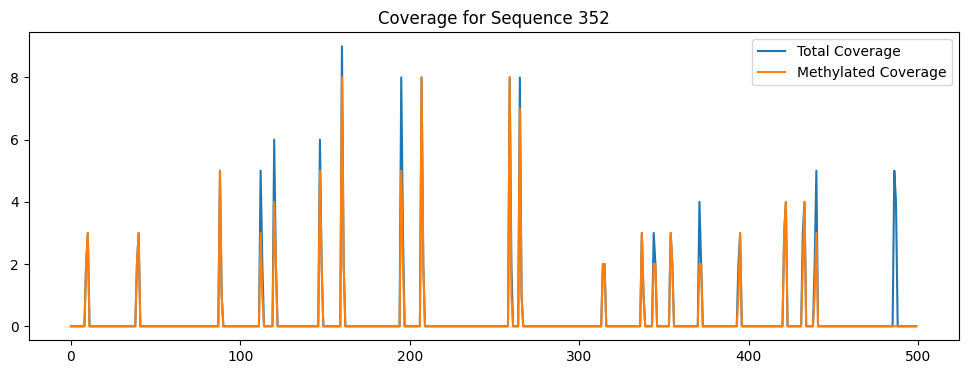

In [14]:
random_idx = torch.randint(0, X_valid.shape[0], (1,)).item()
plt.figure(figsize=(12, 4))
plt.plot(y_cov_valid[random_idx].numpy(), label="Total Coverage")
plt.plot(y_methyl_valid[random_idx].numpy(), label="Methylated Coverage")
plt.legend()
plt.title(f"Coverage for Sequence {random_idx}")
plt.show()

# Model

In [15]:
# 2. Initialize Random Model
model = CpGNet(
    n_filters=64, 
    n_layers=4, 
    min_cov=3, 
    verbose=True, 
    trimming=0,
    name="/cellar/users/aklie/projects/ML4GLand/tutorials/bulk_wgbs_basepair/eugene/fit/fold_0/sample/HepG2_WGBS"
)
model.eval()  # Set to evaluation mode for testing

CpGNet(
  (iconv): Conv1d(4, 64, kernel_size=(21,), stride=(1,), padding=(10,))
  (irelu): ReLU()
  (rconvs): ModuleList(
    (0): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
    (1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(4,))
    (2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(8,), dilation=(8,))
    (3): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(16,), dilation=(16,))
  )
  (rrelus): ModuleList(
    (0-3): 4 x ReLU()
  )
  (fconv): Conv1d(64, 2, kernel_size=(75,), stride=(1,), padding=(37,))
)

In [16]:
# Compute methylation fractions (ensure no division by zero)
y_frac = y_methyl_valid / (y_cov_valid + 1e-8)

# 3. Forward Pass with Randomly Initialized Model
with torch.no_grad():  # No need for gradients during this test
    y_pred = model(X_valid)  # Input shape must be (B, 4, L)

# Extract predicted alpha and beta logits
y_alpha = torch.nn.functional.softplus(y_pred[:, 0, :])  # Predicted alpha parameters
y_beta = torch.nn.functional.softplus(y_pred[:, 1, :])  # Predicted beta parameters

print("Predicted Alpha (shape):", y_alpha.shape)
print("Predicted Beta (shape):", y_beta.shape)

Predicted Alpha (shape): torch.Size([395, 500])
Predicted Beta (shape): torch.Size([395, 500])


In [17]:
learning_rate = 1e-3
max_epochs = 100

In [18]:
# Move the model to the GPU and prepare the optimizer
model.cuda()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
print(f"Optimizer: {optimizer}")

Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [22]:
%load_ext autoreload
%autoreload 2

In [19]:
# Use the models fit_generator method to train the model
print("Fitting the model")
model.fit(
    train_dl,
    optimizer,
    X_valid=X_valid,
    y_cov_valid=y_cov_valid,
    y_methyl_valid=y_methyl_valid,
    max_epochs=max_epochs,
    validation_iter=100,
)

Fitting the model
Epoch	Iteration	Training Time	Validation Time	Training BNLL	Validation BNLL	Validation Pearson	Saved?
0	0	0.6932	0.3399	-2.9007	-6.5589	-0.043	True
3	100	0.0917	0.0083	-7.7144	-6.6562	0.1207	True
6	200	0.1767	0.008	-6.7602	-6.6777	0.1874	True
10	300	0.0895	0.008	-7.4962	-6.6916	0.2083	True
13	400	0.1571	0.0081	-6.4782	-6.6934	0.2264	True
17	500	0.0524	0.008	-7.4581	-6.6862	0.2448	False
20	600	0.1376	0.008	-7.7866	-6.6885	0.2522	False
24	700	0.0328	0.0081	-7.6686	-6.6609	0.2446	False
27	800	0.1183	0.0079	-6.9295	-6.5496	0.2236	False
31	900	0.0133	0.0081	-7.5766	-6.4098	0.2104	False
34	1000	0.0981	0.0079	-7.6616	-6.2736	0.1717	False
37	1100	0.1842	0.0079	-7.4967	-6.1151	0.1443	False
41	1200	0.0786	0.0079	-7.0352	-5.2251	0.1284	False
44	1300	0.1929	0.008	-7.8143	-4.4996	0.1199	False
48	1400	0.0591	0.008	-8.4313	-3.58	0.0933	False
51	1500	0.1462	0.008	-8.1556	-2.0514	0.1319	False
55	1600	0.0393	0.025	-8.0802	0.6583	0.1107	False
58	1700	0.1243	0.008	-7.9512	2.3241	0.1009	F

# Testing

In [30]:
# 4. Calculate BNLL Loss
# In this example, we assume CpG sites will be dynamically detected
cpg_mask = model.detect_cpg_sites(X_valid)  # Shape: (B, L)
coverage_mask = (y_cov_valid >= model.min_cov).float()
final_mask = cpg_mask * coverage_mask
final_mask

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 1., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

In [31]:
np.where(cpg_mask[0])[0]

array([ 26, 183, 202, 253, 259, 292, 336])

In [32]:
np.where(final_mask[0])[0]

array([ 26, 183, 202, 253, 259, 292, 336])

In [33]:
np.where(y_cov_valid[0] > 0.0)[0]

array([ 26,  27, 183, 184, 202, 203, 253, 254, 259, 260, 292, 293, 336,
       337])

In [36]:
valid_data["seq"][0].values[202:204]

array([b'C', b'G'], dtype='|S1')

In [37]:
loss = BNLLLoss(y_alpha, y_beta, y_frac, mask=final_mask)
print(f"BNLL Loss: {loss.item():.4f}")

BNLL Loss: -2.5859


In [38]:
from cpgnet.performance import smooth_gaussian1d, pearson_corr, spearman_corr, jensen_shannon_distance, mean_squared_error
from cpgnet.performance import calculate_performance_measures

In [39]:
import torch

def pearson_corr(arr1, arr2):
    """Pearson correlation, ignoring NaNs."""
    mean1 = torch.nanmean(arr1, dim=-1, keepdim=True)
    mean2 = torch.nanmean(arr2, dim=-1, keepdim=True)
    dev1, dev2 = arr1 - mean1, arr2 - mean2

    numer = torch.nansum(dev1 * dev2, dim=-1)  # Covariance
    denom = torch.sqrt(torch.nansum(dev1 ** 2, dim=-1) * torch.nansum(dev2 ** 2, dim=-1))  # Variances

    corr = numer / denom
    corr[torch.isnan(corr) | (denom == 0)] = float('nan')  # Handle invalid cases
    return corr


def calculate_performance_measures(
    alphas,
    betas,
    fracs,
    mask,
    measures=None,
    batch_size=200
):
    """
    Calculate performance measures for CpG site predictions in batches.

    Parameters
    ----------
    alphas : torch.Tensor
        Predicted alpha parameters for the Beta distribution, shape (B, L).
    betas : torch.Tensor
        Predicted beta parameters for the Beta distribution, shape (B, L).
    fracs : torch.Tensor
        True methylation fractions, shape (B, L).
    mask : torch.Tensor
        Binary mask indicating valid CpG sites, shape (B, L).
    measures : list of str, optional
        List of measures to calculate. Options include:
        - 'bnll': Beta Negative Log-Likelihood loss.
        - 'jsd': Jensen-Shannon Distance.
        - 'pearson': Pearson correlation.
        - 'spearman': Spearman correlation.
        - 'mse': Mean Squared Error.
        If None, all measures will be calculated.
    batch_size : int, optional
        The number of sequences to process in each batch (default: 200).

    Returns
    -------
    dict
        Dictionary of calculated measures, where each value is a tensor of shape (B,).
    """
    measures_ = {m: torch.full((alphas.shape[0],), float('nan'), device=alphas.device) for m in measures or ['bnll', 'jsd', 'pearson', 'spearman', 'mse']}

    n = alphas.shape[0]
    for start in range(0, n, batch_size):
        end = start + batch_size

        # Slice the batch
        batch_alphas = alphas[start:end]
        batch_betas = betas[start:end]
        batch_fracs = fracs[start:end]
        batch_mask = mask[start:end]

        # Calculate predictions
        batch_preds = batch_alphas / (batch_alphas + batch_betas + 1e-8)

        # Replace invalid positions with NaN
        nan_value = torch.tensor(float('nan'), device=batch_fracs.device)
        nan_batch_fracs = torch.where(batch_mask.bool(), batch_fracs, nan_value.expand_as(batch_fracs))
        nan_batch_preds = torch.where(batch_mask.bool(), batch_preds, nan_value.expand_as(batch_preds))

        # Iterate over measures
        for measure in measures_:
            if measure == 'bnll':
                bnll = BNLLLoss(batch_alphas, batch_betas, batch_fracs, mask=batch_mask)
                measures_['bnll'][start:end] = bnll
            elif measure == 'jsd':
                jsd = jensen_shannon_distance(nan_batch_fracs, nan_batch_preds)
                measures_['jsd'][start:end] = jsd
            elif measure == 'pearson':
                pearson = pearson_corr(nan_batch_fracs, nan_batch_preds)
                measures_['pearson'][start:end] = pearson
            elif measure == 'spearman':
                spearman = spearman_corr(nan_batch_fracs, nan_batch_preds)
                measures_['spearman'][start:end] = spearman
            elif measure == 'mse':
                mse = mean_squared_error(nan_batch_fracs, nan_batch_preds)
                measures_['mse'][start:end] = mse

    return measures_

In [40]:
nan_value = torch.tensor(float('nan'), device=y_frac.device)
nan_value

tensor(nan)

In [41]:
y_frac.shape, final_mask.shape

(torch.Size([395, 500]), torch.Size([395, 500]))

In [42]:
# 3. Calculate Performance Metrics
# Define the performance measures to calculate
measures = ['pearson']

# Calculate performance metrics
metrics = calculate_performance_measures(
    alphas=y_alpha,
    betas=y_beta,
    fracs=y_frac,
    mask=final_mask,
    measures=measures,
    batch_size=200
)

metrics

{'pearson': tensor([-0.7188, -0.5777, -0.0973, -0.7079,     nan,  0.2334, -0.0971,     nan,
          0.8741, -0.2624,  0.1728,     nan, -0.5885,  0.3848,     nan,     nan,
          0.6036,  0.3106, -0.3912, -0.2335,     nan,  0.5734,  0.0198, -0.6035,
         -0.7831, -0.0269,  0.4692,     nan, -0.6908, -0.2164, -0.8629,  0.6437,
          0.5467, -0.5264, -0.1975, -0.5177, -0.4469, -0.5689, -0.5134,  0.9282,
          0.1165, -0.5381,  0.7450, -1.0000, -0.8117,     nan,  0.0928,  0.3241,
         -0.2271, -0.4472, -0.0481,     nan, -0.2574,     nan,     nan,     nan,
         -0.2590,  0.9949,  0.0652,  0.0092,  0.1840, -0.7357,  0.3119,     nan,
         -0.2808,  0.4370,  0.7124,  0.7517,  0.2581, -0.2693,     nan,  0.5525,
             nan, -0.2358, -0.6330,     nan,     nan, -0.1719,  0.7892, -0.3464,
         -0.3819, -0.9253, -0.8937,  0.6115, -1.0000,  0.0409, -0.7457, -0.6156,
             nan,  0.8630, -1.0000,     nan, -0.6468,     nan,  0.2464,     nan,
             nan,

In [44]:
# 4. Print Metrics
print("Performance Metrics:")
for measure, value in metrics.items():
    print(f"{measure.upper()}: {np.nanmean(value.cpu().numpy()):.4f}")

Performance Metrics:
PEARSON: -0.0327


In [45]:
preds = y_alpha / (y_alpha + y_beta + 1e-8)

In [46]:
nan_value = torch.tensor(float('nan'), device=y_frac.device)
nan_y_frac = torch.where(final_mask.bool(), y_frac, nan_value.expand_as(y_frac))
nan_preds = torch.where(final_mask.bool(), preds, nan_value.expand_as(preds))

In [47]:
nan_y_frac

tensor([[nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, 1., nan],
        ...,
        [nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan]])

In [48]:
nan_preds

tensor([[   nan,    nan,    nan,  ...,    nan,    nan,    nan],
        [   nan,    nan,    nan,  ...,    nan,    nan,    nan],
        [   nan,    nan,    nan,  ...,    nan, 0.4948,    nan],
        ...,
        [   nan,    nan,    nan,  ...,    nan,    nan,    nan],
        [   nan,    nan,    nan,  ...,    nan,    nan,    nan],
        [   nan,    nan,    nan,  ...,    nan,    nan,    nan]])

In [49]:
pearson_corr(nan_y_frac, nan_preds)

tensor([-0.7188, -0.5777, -0.0973, -0.7079,     nan,  0.2334, -0.0971,     nan,
         0.8741, -0.2624,  0.1728,     nan, -0.5885,  0.3848,     nan,     nan,
         0.6036,  0.3106, -0.3912, -0.2335,     nan,  0.5734,  0.0198, -0.6035,
        -0.7831, -0.0269,  0.4692,     nan, -0.6908, -0.2164, -0.8629,  0.6437,
         0.5467, -0.5264, -0.1975, -0.5177, -0.4469, -0.5689, -0.5134,  0.9282,
         0.1165, -0.5381,  0.7450, -1.0000, -0.8117,     nan,  0.0928,  0.3241,
        -0.2271, -0.4472, -0.0481,     nan, -0.2574,     nan,     nan,     nan,
        -0.2590,  0.9949,  0.0652,  0.0092,  0.1840, -0.7357,  0.3119,     nan,
        -0.2808,  0.4370,  0.7124,  0.7517,  0.2581, -0.2693,     nan,  0.5525,
            nan, -0.2358, -0.6330,     nan,     nan, -0.1719,  0.7892, -0.3464,
        -0.3819, -0.9253, -0.8937,  0.6115, -1.0000,  0.0409, -0.7457, -0.6156,
            nan,  0.8630, -1.0000,     nan, -0.6468,     nan,  0.2464,     nan,
            nan,     nan,  1.0000,  0.99

In [50]:
y_frac[0]

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0400,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 

In [51]:
preds

tensor([[0.4729, 0.4722, 0.4712,  ..., 0.4970, 0.4951, 0.4953],
        [0.4744, 0.4769, 0.4953,  ..., 0.4745, 0.5232, 0.4846],
        [0.5037, 0.4890, 0.5365,  ..., 0.4980, 0.4948, 0.5467],
        ...,
        [0.4734, 0.4761, 0.4603,  ..., 0.4931, 0.4607, 0.5052],
        [0.4858, 0.5236, 0.4725,  ..., 0.5139, 0.4965, 0.4860],
        [0.4450, 0.5101, 0.4898,  ..., 0.5116, 0.5215, 0.4868]])

In [52]:
metrics

{'pearson': tensor([-0.7188, -0.5777, -0.0973, -0.7079,     nan,  0.2334, -0.0971,     nan,
          0.8741, -0.2624,  0.1728,     nan, -0.5885,  0.3848,     nan,     nan,
          0.6036,  0.3106, -0.3912, -0.2335,     nan,  0.5734,  0.0198, -0.6035,
         -0.7831, -0.0269,  0.4692,     nan, -0.6908, -0.2164, -0.8629,  0.6437,
          0.5467, -0.5264, -0.1975, -0.5177, -0.4469, -0.5689, -0.5134,  0.9282,
          0.1165, -0.5381,  0.7450, -1.0000, -0.8117,     nan,  0.0928,  0.3241,
         -0.2271, -0.4472, -0.0481,     nan, -0.2574,     nan,     nan,     nan,
         -0.2590,  0.9949,  0.0652,  0.0092,  0.1840, -0.7357,  0.3119,     nan,
         -0.2808,  0.4370,  0.7124,  0.7517,  0.2581, -0.2693,     nan,  0.5525,
             nan, -0.2358, -0.6330,     nan,     nan, -0.1719,  0.7892, -0.3464,
         -0.3819, -0.9253, -0.8937,  0.6115, -1.0000,  0.0409, -0.7457, -0.6156,
             nan,  0.8630, -1.0000,     nan, -0.6468,     nan,  0.2464,     nan,
             nan,